# Notebook for visualization of a simulated dataset

In [1]:
# Import simulated datasets from simulated_dataset_1 and plot it
import sys
sys.path.append('../')
sys.path.append('../../')
from data_loader.simulated_dataset import SimulatedDataset
import numpy as np
from data_loader.simulated_data_models import Simulation
import os

In [2]:
sim = Simulation(seed=0)

In [3]:
# lambda_funcs = {
#     "Periodic": lambda t: (percent_pts * 100 / end_time) * (1 + 0.5 * np.sin(2 * np.pi * t / end_time)),
#     "Ramp-up": lambda t: (percent_pts * 100 / end_time) * (0.5 + 0.5 * (t / end_time)),
#     "Drop-off": lambda t: (percent_pts * 100 / end_time) * (1.0 - 0.5 * (t / end_time)),
# }

## OU Model

In [4]:
percent_pts = 0.52
n_samples = 1000
end_time = 7.0

ds_ou = sim.generate_simulated_dataset(
    n_samples=n_samples,
    n_sampling_times=200,
    end_time=end_time,
    n_static_feats=2,
    dim=3,
    scale=np.array([0.2, 1, 0.5, 0.05]),
    xi=0.1,                 # diffusion amplitude in OU
    threshold=100,
    hurst=0.4,              # long memory in “noise”
    percent_pts=percent_pts,
    missing=True,
    var_static=0.07,
    lambda_func = "from_paths", # lambda t:  ((percent_pts*100/end_time) + (1 - (percent_pts*100/end_time)) * (1/2) * np.sin(-2 * np.pi * t / end_time)),
    missing_static_rate=0,
    model='ou',
    correlated=False, 
    cond_init=True,
)


46
35
47
47
37
45
46
42
44
37
50
41
49
54
43
45
51
43
42
42
50
37
44
40
42
58
43
54
40
50
43
58
57
40
32
51
45
46
42
51
44
44
32
32
31
37
39
44
39
42
42
47
43
54
37
41
41
44
37
40
43
45
37
38
45
40
49
51
47
35
43
47
44
44
34
43
50
53
50
49
49
53
52
46
48
41
39
54
52
37
38
49
46
51
41
32
40
44
51
42
35
44
40
44
47
44
38
45
43
53
48
43
46
44
45
48
63
39
50
47
53
37
48
60
37
47
41
40
31
41
42
47
49
44
43
46
42
44
43
57
48
43
42
51
42
45
40
54
53
50
48
41
38
45
48
45
40
48
40
54
43
48
43
38
46
41
39
38
49
42
37
46
56
41
54
42
43
45
49
39
53
38
41
55
44
45
44
54
40
43
48
42
51
40
46
50
43
44
45
53
49
51
41
51
45
49
45
44
42
46
42
46
50
40
39
38
61
44
40
50
47
43
59
43
41
40
41
44
41
40
43
40
39
39
52
56
42
41
44
43
58
42
52
45
51
47
40
43
39
51
48
37
49
42
42
50
51
32
48
38
43
45
47
42
47
47
36
34
49
56
46
46
45
48
37
39
43
44
47
49
38
37
31
38
32
46
51
42
46
50
48
46
42
40
49
53
50
39
43
35
44
36
39
47
49
46
46
43
62
53
44
51
41
46
46
46
41
48
49
38
48
41
46
38
52
48
43
55
49
51
41
51
50
4

In [5]:
N_obs_mean = 50
constant = N_obs_mean / (ds_ou.sampling_times[-1] * np.mean(
    np.exp(-ds_ou.paths.sum(axis=2)).mean(axis=1)
))

print(constant)

52.152247352730214


In [6]:
mask = ~np.isnan(ds_ou.irr_paths_NaN)
n_pts_mean = []
for i in range(ds_ou.n_samples):
    n_pts_mean.append(np.sum(mask[i,:,1:].any(axis=-1)))
print(f"Average number of points per sample: {np.mean(n_pts_mean)}")

Average number of points per sample: 45.023


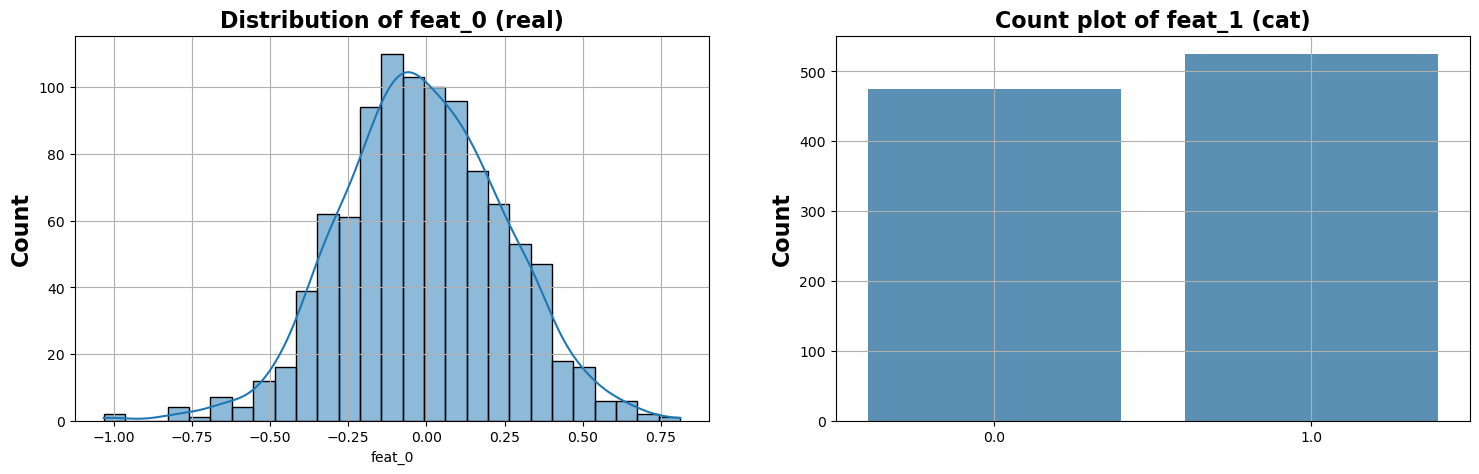

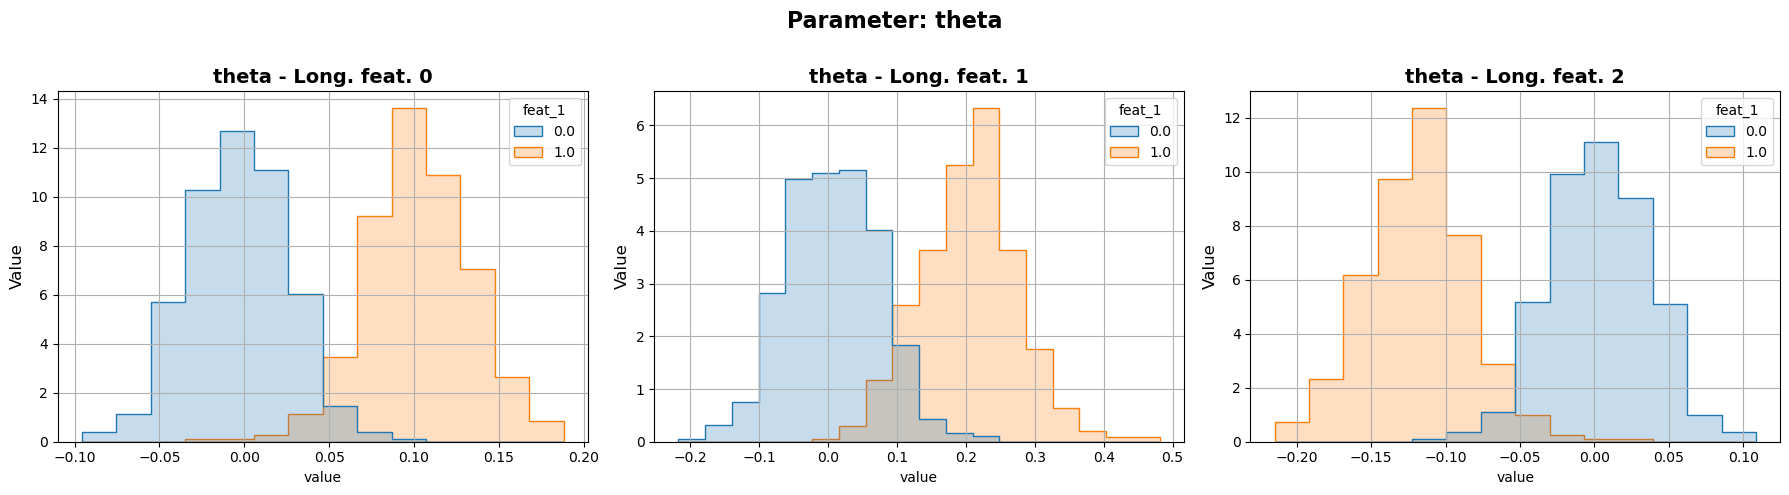

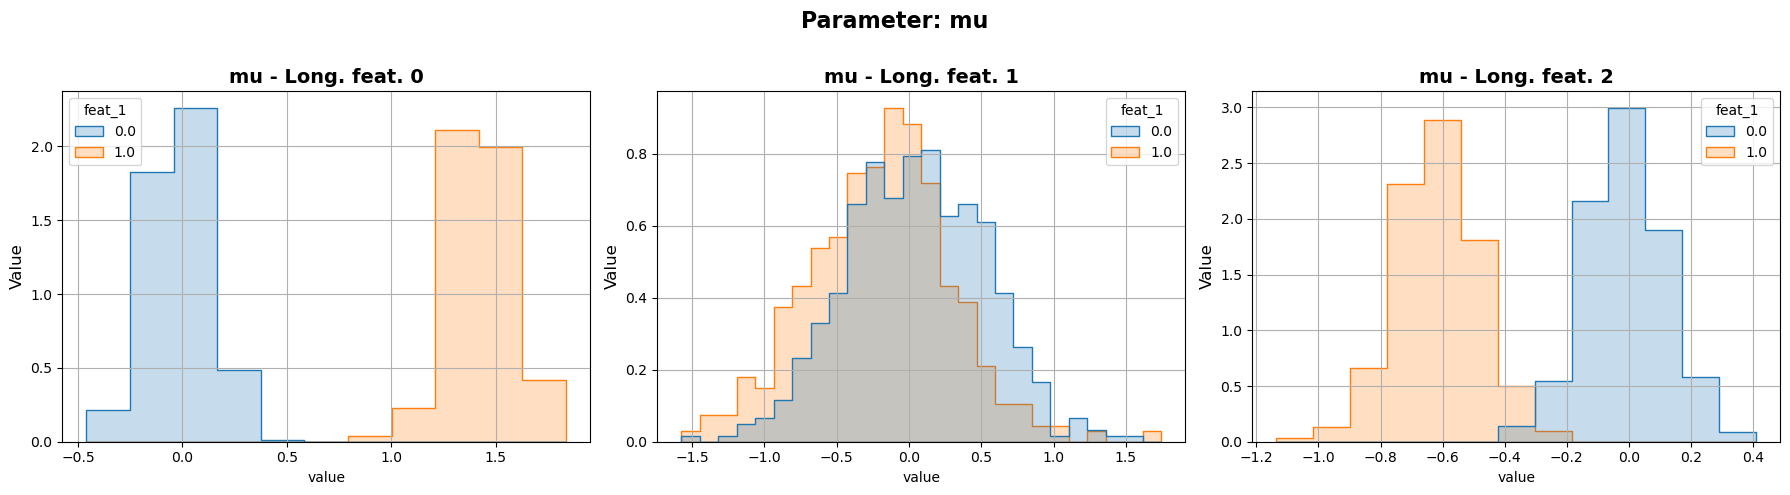

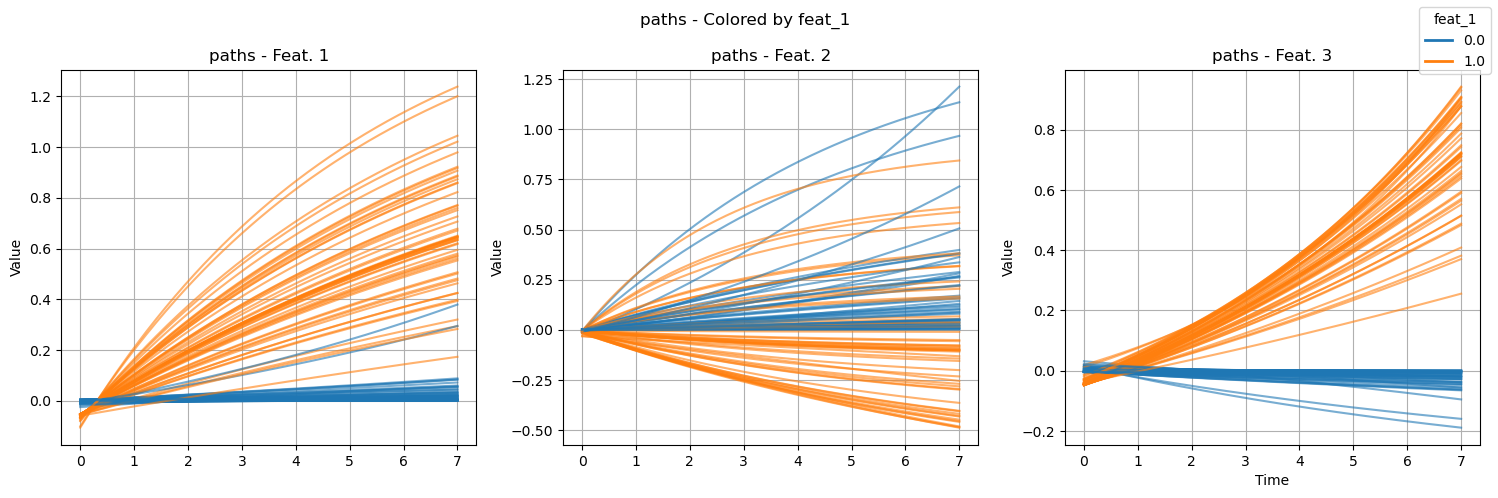

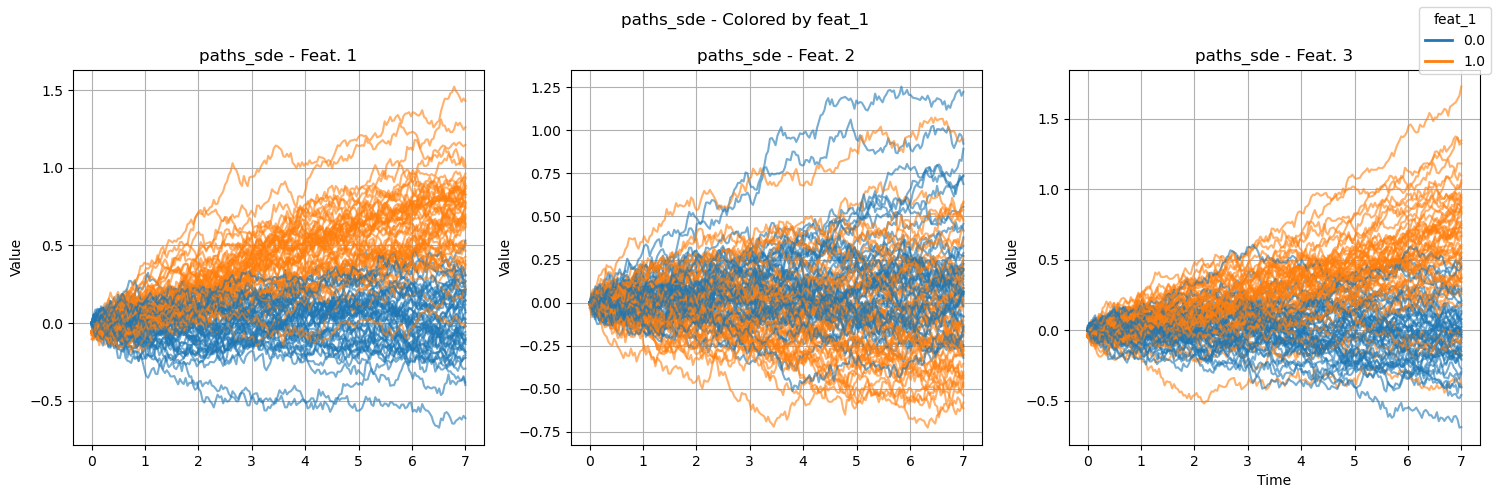

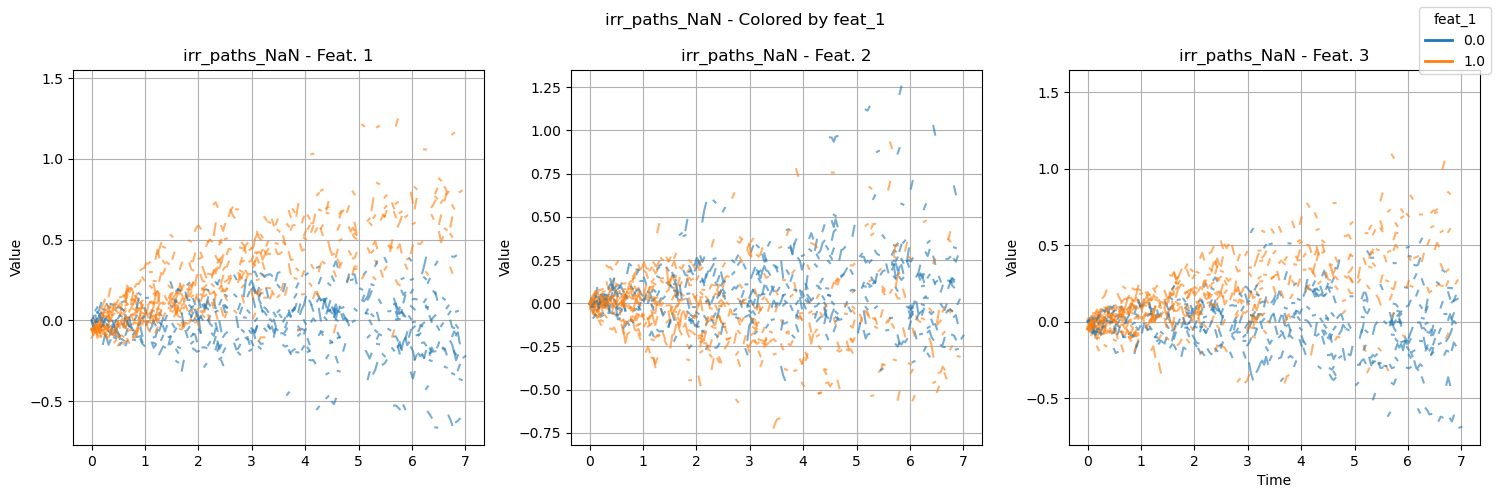

TypeError: 'str' object is not callable

In [7]:
ds_ou.plot_static_feats()
ds_ou.plot_model_params(feat_comparison_name="feat_1")
ds_ou.plot_longitudinal_feats(feat_comparison_name="feat_1", n_samples_to_plot=100)
ds_ou.plot_lambda_func_vs_events()

## Gompertz Model

In [ ]:
percent_pts = 0.6
end_time = 4.0

ds_gomp = sim.generate_simulated_dataset(
    n_samples=3000,
    n_sampling_times=200,
    end_time=end_time,
    n_static_feats=2,
    dim=5,
    scale=np.array([0.3, 1, 0.1]),
    xi=0.5,                 # unused here, harmless
    threshold=7.0,
    hurst=0.6,
    percent_pts=percent_pts,
    missing=True,
    var_static=0.15,
    lambda_func= lambda t: (percent_pts * 100 / end_time) * (1.0 - 0.5 * (t / end_time)), # "Drop-off"
    missing_static_rate=0.05,
    model='gompertz'
)

In [ ]:
ds_gomp.plot_static_feats()
ds_gomp.plot_model_params(feat_comparison_name="feat_1")
ds_gomp.plot_longitudinal_feats(feat_comparison_name="feat_1", n_samples_to_plot=100)
ds_gomp.plot_lambda_func_vs_events()

## CIR Model

In [ ]:
percent_pts = 0.6
end_time = 5.0

ds_cir = sim.generate_simulated_dataset(
    n_samples=3000,
    n_sampling_times=200,
    end_time=end_time,
    n_static_feats=6,
    dim=5,
    scale=0.01,
    xi=0.5,                 # unused in CIR, harmless
    threshold=5.0,
    hurst=0.7,
    percent_pts=percent_pts,
    missing=True,
    var_static=0.15,
    lambda_func= lambda t: (percent_pts * 100 / end_time) * (1 + 0.5 * np.sin(2 * np.pi * t / end_time)), # "Periodic"
    missing_static_rate=0.10,
    model='cir'
)

In [ ]:
ds_cir.plot_static_feats()

In [ ]:
ds_cir.plot_model_params(feat_comparison_name="feat_3")

In [ ]:
ds_cir.plot_longitudinal_feats(feat_comparison_name="feat_3", n_samples_to_plot=100)

In [ ]:
ds_cir.plot_lambda_func_vs_events()